# Garbé-Kourou reforecast

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.datasources import grdc, glofas
from src.utils.rp_calc import calculate_one_group_rp
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [62]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [63]:
def date_to_season(date):
    if date.month < 6:
        return date.year - 1
    else:
        return date.year

In [64]:
df_grdc["season"] = df_grdc["time"].apply(date_to_season)

In [65]:
def set_flood_phase(date):
    if date.month >= 6 and date.month <= 9:
        return "l"
    else:
        return "g"

In [66]:
df_grdc["flood_type"] = df_grdc["time"].apply(set_flood_phase)

In [67]:
min_season, max_season = 1979, 2024

In [68]:
df_grdc = df_grdc[(df_grdc["season"].isin(range(min_season, max_season + 1)))]

In [69]:
df_grdc["level"] = calculate_stage(df_grdc["runoff_mean"])

In [70]:
df_locale = df_grdc[df_grdc["flood_type"] == "l"]
df_gui = df_grdc[df_grdc["flood_type"] == "g"]

In [71]:
df_locale

,time,runoff_mean,season,flood_type,level
18413,1979-06-01,24.420000,1979,l,144.867346
18414,1979-06-02,22.330000,1979,l,143.093793
18415,1979-06-03,20.240000,1979,l,141.284662
18416,1979-06-04,19.200001,1979,l,140.370486
18417,1979-06-05,21.290001,1979,l,142.198138
...,...,...,...,...,...
34967,2024-09-26,NaN,2024,l,NaN
34968,2024-09-27,NaN,2024,l,NaN
34969,2024-09-28,NaN,2024,l,NaN
34970,2024-09-29,NaN,2024,l,NaN


In [72]:
df_rea_niamey = glofas.load_reanalysis("niamey")

In [113]:
df_rea_niamey["season"] = df_rea_niamey["time"].apply(date_to_season)

In [147]:
df_plot = df_rea_niamey.copy()
df_plot["plot_date"] = df_plot["time"].map(
    lambda x: pd.Timestamp(
        year=1904,
        month=x.month,
        day=x.day,
    )
)

[None, None]

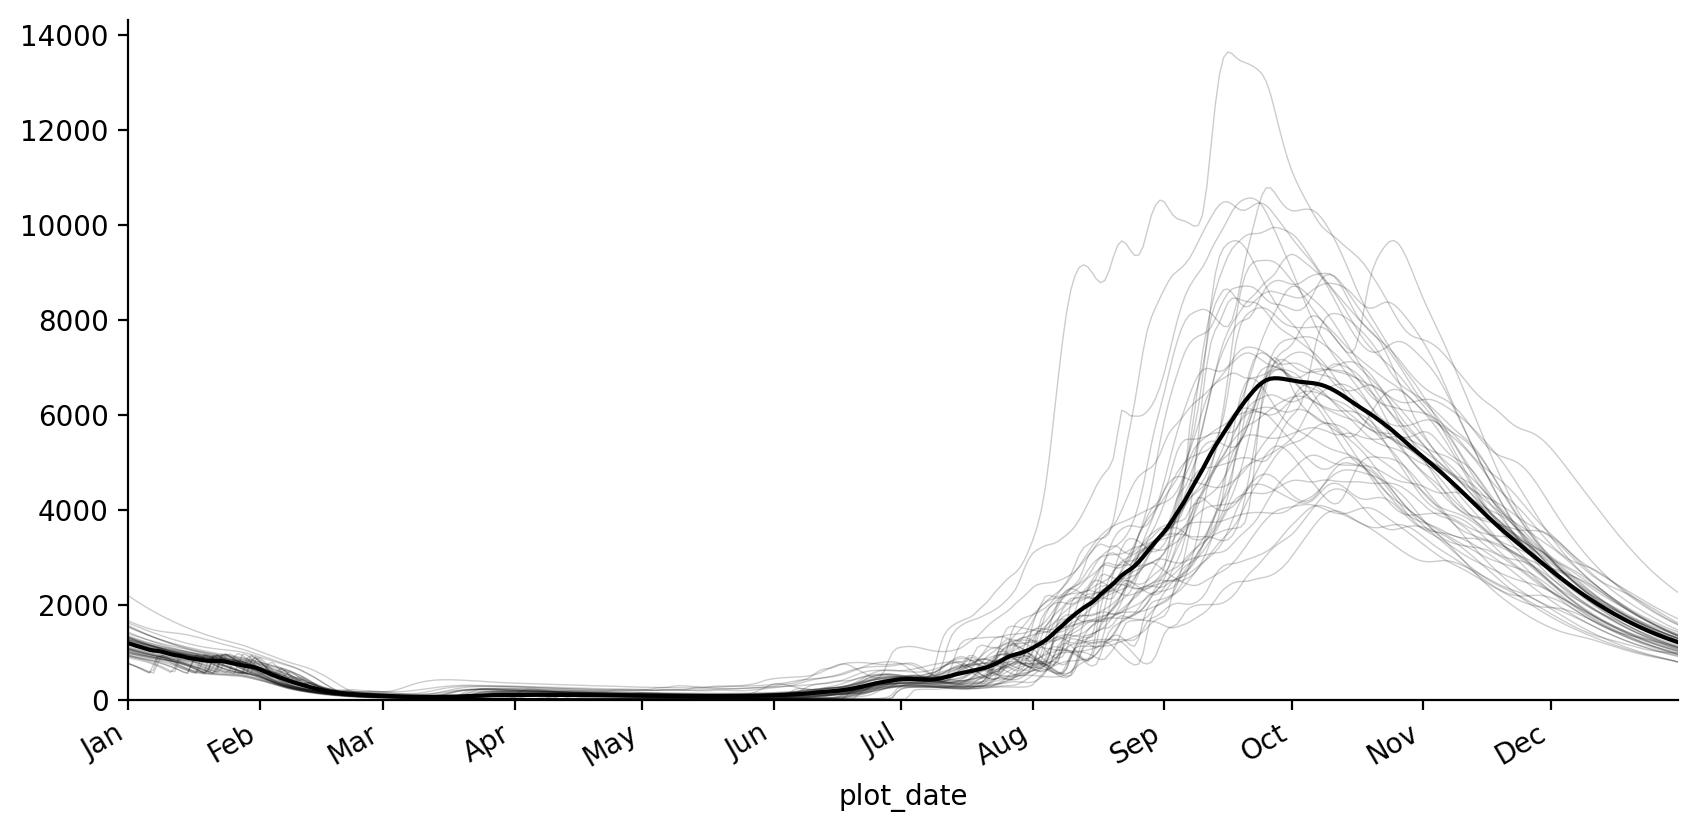

In [148]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    group.plot(
        x="plot_date",
        y="dis24",
        ax=ax,
        legend=False,
        color="k",
        alpha=0.2,
        linewidth=0.5,
    )

df_plot.groupby("plot_date")["dis24"].mean().plot(ax=ax, color="k")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(bottom=0)
ax.set_xlim((df_plot["plot_date"].min(), df_plot["plot_date"].max()))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

<Axes: xlabel='time'>

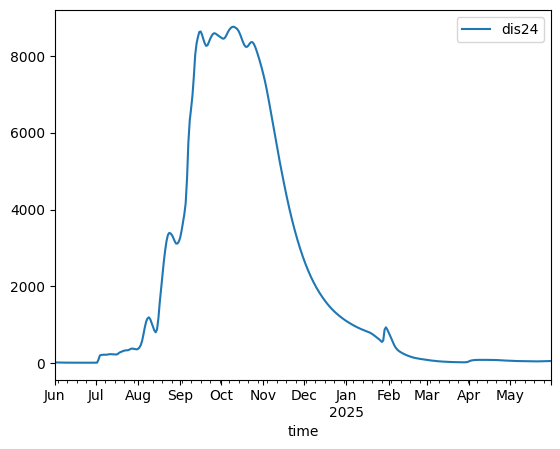

In [151]:
df_rea_niamey.set_index("season").loc[2024].plot(x="time", y="dis24")

In [74]:
df_gui = df_gui.merge(df_rea_niamey)

In [93]:
df_gui_peaks = df_gui.groupby("season")[["dis24", "level"]].max().reset_index()

<Axes: xlabel='dis24', ylabel='level'>

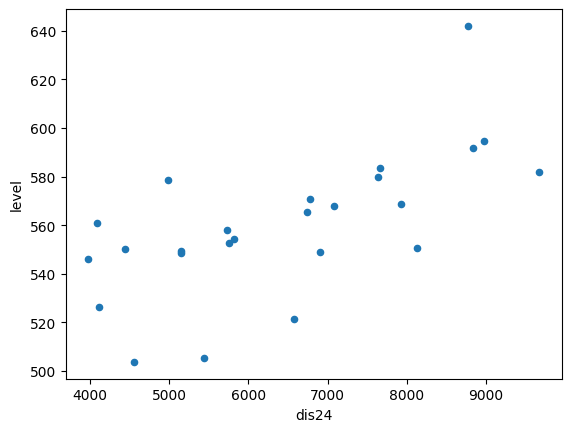

In [94]:
df_gui_peaks[df_gui_peaks["season"] >= 2000].plot.scatter(x="dis24", y="level")

In [102]:
df_gui_peaks = calculate_one_group_rp(
    df_gui_peaks, col_name="dis24", ascending=False
)
df_gui_peaks = calculate_one_group_rp(
    df_gui_peaks, col_name="level", ascending=False
)

In [115]:
df_rea_peaks = df_rea_niamey.groupby("season")["dis24"].max().reset_index()

In [119]:
df_rea_peaks = calculate_one_group_rp(
    df_rea_peaks, col_name="dis24", ascending=False
)

In [120]:
thresh_action = 600

In [142]:
rp_readiness = 4

In [159]:
df_gui_peaks = df_gui_peaks.sort_values("dis24_rp")
thresh_readiness_g_oct = np.interp(
    rp_readiness, df_gui_peaks["dis24_rp"], df_gui_peaks["dis24"]
)
df_rea_peaks = df_rea_peaks.sort_values("dis24_rp")
thresh_readiness_g = np.interp(
    rp_readiness, df_rea_peaks["dis24_rp"], df_rea_peaks["dis24"]
)

In [144]:
thresh_readiness_g

8752.889668367347

In [162]:
dicts = []
for season in df_gui["season"].unique():
    dff_trig = df_rea_niamey[
        (df_rea_niamey["dis24"] >= thresh_readiness_g)
        & (df_rea_niamey["season"] == season)
    ]
    dff_trig_oct_only = df_gui[
        (df_gui["dis24"] >= thresh_readiness_g_oct)
        & (df_gui["season"] == season)
    ]
    dff_actual = df_gui[
        (df_gui["level"] >= thresh_action) & (df_gui["season"] == season)
    ]
    dicts.append(
        {
            "season": season,
            "readiness_date": dff_trig["time"].min(),
            "readiness_date_oct": dff_trig_oct_only["time"].min(),
            "action_date": dff_actual["time"].min(),
        }
    )

df_gui_timing = pd.DataFrame(dicts)

In [163]:
df_gui_timing

,season,readiness_date,readiness_date_oct,action_date
0,1979,1979-08-11,1979-10-01,1979-12-30
1,1980,1980-09-08,1980-10-01,NaT
2,1981,NaT,NaT,NaT
3,1982,NaT,NaT,NaT
4,1983,NaT,NaT,NaT
5,1984,NaT,NaT,NaT
6,1985,1985-09-19,1985-10-01,NaT
7,1986,NaT,NaT,NaT
8,1987,NaT,NaT,NaT
9,1988,1988-09-14,1988-10-01,NaT


In [165]:
(2025 - 1979 + 1 + 1) / 12

4.0

In [166]:
df_rea_gk = glofas.load_reanalysis("garbekourou")

In [173]:
df_rea_gk

,time,dis24
0,1979-01-01,0.656250
1,1979-01-02,0.625000
2,1979-01-03,0.593750
3,1979-01-04,0.562500
4,1979-01-05,0.546875
...,...,...
16797,2024-12-27,0.054688
16798,2024-12-28,0.054688
16799,2024-12-29,0.046875
16800,2024-12-30,0.046875


In [170]:
df_ref_gk = glofas.load_reforecast("garbekourou")
df_ref_gk = df_ref_gk[df_ref_gk["leadtime"] <= 7]

In [171]:
df_ref_gk

,dis24,valid_time,time,leadtime
2450,71.187500,2003-07-04,2003-07-03,1
2695,71.187500,2003-07-04,2003-07-03,1
2940,71.187500,2003-07-04,2003-07-03,1
3185,71.187500,2003-07-04,2003-07-03,1
3430,71.187500,2003-07-04,2003-07-03,1
...,...,...,...,...
100841,5.886719,2023-11-07,2023-10-31,7
101093,5.867188,2023-11-07,2023-10-31,7
101345,5.859375,2023-11-07,2023-10-31,7
101597,5.875000,2023-11-07,2023-10-31,7


In [174]:
df_locale = df_locale.merge(df_rea_gk)

In [176]:
df_locale

,time,runoff_mean,season,flood_type,level,dis24
0,1979-06-01,24.420000,1979,l,144.867346,22.187500
1,1979-06-02,22.330000,1979,l,143.093793,24.281250
2,1979-06-03,20.240000,1979,l,141.284662,24.937500
3,1979-06-04,19.200001,1979,l,140.370486,23.781250
4,1979-06-05,21.290001,1979,l,142.198138,22.437500
...,...,...,...,...,...,...
5607,2024-09-26,NaN,2024,l,NaN,381.835938
5608,2024-09-27,NaN,2024,l,NaN,359.054688
5609,2024-09-28,NaN,2024,l,NaN,329.609375
5610,2024-09-29,NaN,2024,l,NaN,298.734375


In [178]:
df_loc_peaks = (
    df_locale.groupby("season")[["level", "dis24"]].max().reset_index()
)

In [180]:
df_loc_peaks = calculate_one_group_rp(df_loc_peaks, "dis24", ascending=False)
df_loc_peaks = calculate_one_group_rp(df_loc_peaks, "level", ascending=False)

In [183]:
df_loc_peaks = df_loc_peaks.sort_values("dis24_rp")
gk_rea_thresh = np.interp(
    rp_readiness, df_loc_peaks["dis24_rp"], df_loc_peaks["dis24"]
)

In [184]:
gk_rea_thresh

875.0910904255319

In [235]:
dicts = []
for season, group in df_locale.groupby("season"):
    dff_trig = group[(group["dis24"] >= gk_rea_thresh)]
    dff_actual = group[(group["level"] >= thresh_action)]
    dff_red = group[group["level"] >= 620]
    dicts.append(
        {
            "season": season,
            "readiness_date": dff_trig["time"].min(),
            "action_date": dff_actual["time"].min(),
            "red_date": dff_red["time"].min(),
        }
    )

df_loc_timing = pd.DataFrame(dicts)
df_loc_timing["action_lt"] = (
    df_loc_timing["red_date"] - df_loc_timing["action_date"]
)
df_loc_timing["readiness_lt"] = (
    df_loc_timing["red_date"] - df_loc_timing["readiness_date"]
)

In [236]:
df_loc_timing["readiness_lt"].mean()

Timedelta('1 days 12:00:00')

In [237]:
df_loc_timing["action_lt"].mean()

Timedelta('1 days 10:17:08.571428571')

In [198]:
df_ref_gk["season"] = df_ref_gk["valid_time"].apply(date_to_season)

In [199]:
df_ref_gk

,dis24,valid_time,time,leadtime,season
2450,71.187500,2003-07-04,2003-07-03,1,2003
2695,71.187500,2003-07-04,2003-07-03,1,2003
2940,71.187500,2003-07-04,2003-07-03,1,2003
3185,71.187500,2003-07-04,2003-07-03,1,2003
3430,71.187500,2003-07-04,2003-07-03,1,2003
...,...,...,...,...,...
100841,5.886719,2023-11-07,2023-10-31,7,2023
101093,5.867188,2023-11-07,2023-10-31,7,2023
101345,5.859375,2023-11-07,2023-10-31,7,2023
101597,5.875000,2023-11-07,2023-10-31,7,2023


In [207]:
dfs = []
dicts = []
for lt in df_ref_gk["leadtime"].unique():
    dff = df_ref_gk[df_ref_gk["leadtime"] <= lt]
    dff_peaks = dff.groupby("season")["dis24"].max().reset_index()
    dff_peaks = calculate_one_group_rp(
        dff_peaks, col_name="dis24", ascending=False
    )
    dff_peaks = dff_peaks.sort_values("dis24_rp")
    thresh_lt = np.interp(
        rp_readiness, dff_peaks["dis24_rp"], dff_peaks["dis24"]
    )
    dicts.append({"lt_max": lt, "thresh": thresh_lt})
    dff_trig = dff[dff["dis24"] >= thresh_lt]
    dff_timing = dff_trig.groupby("season")["time"].min().reset_index()
    dff_timing["lt_max"] = lt
    dfs.append(dff_timing)

In [225]:
df_timing_pivot = pd.concat(dfs, ignore_index=True).pivot(
    index="season", columns="lt_max", values="time"
)
df_timing_pivot = df_timing_pivot.rename(
    columns={x: f"ltmax{x}" for x in df_timing_pivot.columns}
).reset_index()
df_timing_pivot.columns.name = None

In [226]:
df_timing_pivot

,season,ltmax1,ltmax2,ltmax3,ltmax4,ltmax5,ltmax6,ltmax7
0,2004,NaT,NaT,2004-08-22,2004-08-22,2004-08-22,NaT,NaT
1,2009,2009-09-04,2009-09-04,2009-08-31,NaT,NaT,NaT,NaT
2,2010,2010-09-04,2010-09-04,NaT,NaT,2010-08-12,2010-08-12,2010-08-12
3,2011,NaT,NaT,NaT,NaT,NaT,2011-08-17,NaT
4,2012,2012-08-17,2012-08-15,2012-09-05,2012-08-05,2012-08-05,2012-08-05,2012-08-05
5,2015,NaT,NaT,NaT,NaT,NaT,2015-08-05,2015-08-05
6,2016,NaT,NaT,NaT,NaT,NaT,NaT,2016-08-24
7,2017,NaT,2017-09-16,2017-09-16,2017-09-07,2017-09-07,2017-09-07,2017-08-17
8,2018,2018-09-04,NaT,NaT,NaT,NaT,NaT,NaT
9,2019,2019-09-02,NaT,NaT,NaT,NaT,NaT,NaT


In [228]:
df_ref_timing = df_timing_pivot.merge(df_loc_timing)

In [247]:
dicts = []
for lt in range(1, 8):
    ref_col = f"ltmax{lt}"
    tps = (
        ~df_ref_timing[ref_col].isnull() & ~df_ref_timing["red_date"].isnull()
    )
    tp = tps.sum()
    readiness_lts = df_ref_timing["red_date"] - df_ref_timing[ref_col]
    print(readiness_lts)
    dicts.append(
        {"lt_max": lt, "tp": tp, "readiness_lt": readiness_lts.mean()}
    )

0        NaT
1        NaT
2        NaT
3        NaT
4     1 days
5        NaT
6        NaT
7        NaT
8        NaT
9    -2 days
10       NaT
11       NaT
dtype: timedelta64[ns]
0       NaT
1       NaT
2       NaT
3       NaT
4    3 days
5       NaT
6       NaT
7       NaT
8       NaT
9       NaT
10      NaT
11      NaT
dtype: timedelta64[ns]
0         NaT
1         NaT
2         NaT
3         NaT
4    -18 days
5         NaT
6         NaT
7         NaT
8         NaT
9         NaT
10        NaT
11        NaT
dtype: timedelta64[ns]
0        NaT
1        NaT
2        NaT
3        NaT
4    13 days
5        NaT
6        NaT
7        NaT
8        NaT
9        NaT
10       NaT
11       NaT
dtype: timedelta64[ns]
0        NaT
1        NaT
2        NaT
3        NaT
4    13 days
5        NaT
6        NaT
7        NaT
8        NaT
9        NaT
10       NaT
11       NaT
dtype: timedelta64[ns]
0        NaT
1        NaT
2        NaT
3        NaT
4    13 days
5    -1 days
6        NaT
7        NaT
8

In [243]:
readiness_lts

0        NaT
1        NaT
2        NaT
3        NaT
4    13 days
5    -1 days
6        NaT
7        NaT
8        NaT
9        NaT
10       NaT
11       NaT
dtype: timedelta64[ns]

In [244]:
df_ref_metrics = pd.DataFrame(dicts)

In [245]:
df_ref_metrics

,lt_max,tp,readiness_lt
0,1,2,-1 days +12:00:00
1,2,1,3 days 00:00:00
2,3,1,-18 days +00:00:00
3,4,1,13 days 00:00:00
4,5,1,13 days 00:00:00
5,6,2,6 days 00:00:00
6,7,2,6 days 00:00:00
